# COVID-19 Patient Risk Analysis: Support Vector Machine (SVM)

สมุดงานนี้พัฒนาและประเมินผลโมเดล **Support Vector Machine (SVM)** เพื่อทำนายสถานะการเสียชีวิตของผู้ป่วย COVID-19 (`DEATH_STATUS`: 0 = Survived, 1 = Died) โดยครอบคลุมทั้ง 4 ส่วนหลักตามบรีฟของโปรเจกต์อย่างครบถ้วนและถูกต้องที่สุด

## 1. ตารางสำรวจข้อมูลก่อนเทรน (Data Exploration Tables)

### 1.1 Dataset Overview

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from src.evaluate import evaluate_classifier, print_metrics, save_metrics
from src.preprocess import build_preprocessor, get_train_test_data, load_dataset

raw_df = pd.read_csv(PROJECT_ROOT / 'data' / 'COVID19_Patient_Risk_Analysis.csv', low_memory=False)
X_clean, y_clean = load_dataset()

# ตารางที่ 1: Dataset Overview
overview_table = pd.DataFrame([
    {'หัวข้อ': 'จำนวนแถวทั้งหมด (Rows)', 'รายละเอียด': f"{raw_df.shape[0]:,} แถว"},
    {'หัวข้อ': 'จำนวนคอลัมน์ทั้งหมด (Columns)', 'รายละเอียด': f"{raw_df.shape[1]} คอลัมน์"},
    {'หัวข้อ': 'จำนวน Features ที่ใช้เทรน', 'รายละเอียด': f"{X_clean.shape[1]} ตัวแปร (1 Numeric, 17 Categorical)"},
    {'หัวข้อ': 'ตัวแปรเป้าหมาย (Target)', 'รายละเอียด': 'DEATH_STATUS (0 = Survived, 1 = Died)'},
    {'หัวข้อ': 'การป้องกัน Data Leakage', 'รายละเอียด': 'ตัด DATE_DIED, RECOVERY_STATUS, RISK_CATEGORY ออก'}
])
overview_table

หัวข้อ,รายละเอียด
จำนวนแถวทั้งหมด (Rows),"25,000 แถว"
จำนวนคอลัมน์ทั้งหมด (Columns),38 คอลัมน์
จำนวน Features ที่ใช้เทรน,"18 ตัวแปร (1 Numeric, 17 Categorical)"
ตัวแปรเป้าหมาย (Target),"DEATH_STATUS (0 = Survived, 1 = Died)"
การป้องกัน Data Leakage,"ตัด DATE_DIED, RECOVERY_STATUS, RISK_CATEGORY ออก"


### 1.2 Target Distribution (การกระจายตัวของตัวแปรเป้าหมาย)

In [2]:
# ตารางที่ 2: Target Distribution
target_dist = pd.DataFrame({
    'จำนวน': raw_df['DEATH_STATUS'].value_counts(),
    'สัดส่วน (%)': (raw_df['DEATH_STATUS'].value_counts(normalize=True) * 100).map('{:.2f}%'.format)
})
target_dist

DEATH_STATUS,จำนวน,สัดส่วน (%)
Survived,"23,166",92.66%
Died,"1,834",7.34%


### 1.3 Missing Values Table (การจัดการรหัส 97, 98, 99)
ในชุดข้อมูลดิบ ค่า 97, 98, 99 เป็นรหัสพิเศษที่แปลว่า *ไม่ทราบข้อมูลหรือไม่เกี่ยวข้อง* โดยเฉพาะ `PREGNANT` มีถึง 49.77% (ส่วนใหญ่เป็นผู้ป่วยเพศชายที่ไม่ได้ตรวจการตั้งครรภ์) ทั้งหมดถูกแปลงเป็น `NaN` เพื่อให้ Imputer จัดการต่อไป ยกเว้น `AGE` ที่ค่า 97-99 ปีเป็นอายุจริง

In [3]:
# ตารางที่ 3: Missing Values Table
missing_cnt = X_clean.isna().sum()
missing_pct = (missing_cnt / len(X_clean) * 100)
missing_table = pd.DataFrame({
    'จำนวน Missing': missing_cnt,
    'สัดส่วน Missing (%)': missing_pct.map('{:.2f}%'.format)
})
missing_table = missing_table[missing_cnt > 0].sort_values(by='จำนวน Missing', ascending=False)
missing_table

Feature,จำนวน Missing,สัดส่วน Missing (%)
PREGNANT,"12,443",49.77%
PNEUMONIA,393,1.57%
OTHER_DISEASE,112,0.45%
INMSUPR,77,0.31%
OBESITY,73,0.29%
TOBACCO,71,0.28%
DIABETES,67,0.27%
CARDIOVASCULAR,66,0.26%
RENAL_CHRONIC,66,0.26%
COPD,62,0.25%


### 1.4 Duplicate Audit (การตรวจสอบข้อมูลซ้ำทั้งแถว)
ตรวจพบข้อมูลซ้ำทั้งแถว **11,992 แถว** (คิดเป็น 47.97% ของชุดข้อมูลดิบ)
> **การตัดสินใจ (Decision Rationale):**
> ข้อมูลซ้ำทั้งแถว **ไม่ควรถูกลบทันที** เพราะชุดข้อมูลนี้ไม่มี ID ผู้ป่วยกำกับ ในความเป็นจริงทางการแพทย์ มีความเป็นไปได้สูงมากที่ผู้ป่วยคนละคนจะมีคุณลักษณะตรงกัน เช่น ผู้ป่วยชาย อายุ 45 ปี มีประวัติเป็นโรคเบาหวานและความดันเหมือนกัน การตัดข้อมูลซ้ำทิ้งจะทำให้สูญเสียสัดส่วนการกระจายตัวจริงของประชากร ดังนั้นจึงตัดสินใจคงข้อมูลไว้ และให้ทั้งสองโมเดลใช้ชุดข้อมูลเดียวกัน

In [4]:
# ตารางที่ 4: Duplicate Audit
dup_count = raw_df.duplicated().sum()
dup_table = pd.DataFrame([
    {'ประเภทข้อมูล': 'แถวข้อมูลที่ไม่ซ้ำ (Unique Rows)', 'จำนวน': f"{len(raw_df) - dup_count:,}", 'สัดส่วน': f"{(len(raw_df) - dup_count)/len(raw_df):.2%}"},
    {'ประเภทข้อมูล': 'แถวข้อมูลที่ซ้ำกันทั้งแถว (Duplicate Rows)', 'จำนวน': f"{dup_count:,}", 'สัดส่วน': f"{dup_count/len(raw_df):.2%}"},
    {'ประเภทข้อมูล': 'รวมทั้งหมด (Total Rows)', 'จำนวน': f"{len(raw_df):,}", 'สัดส่วน': '100.00%'}
])
dup_table

ประเภทข้อมูล,จำนวน,สัดส่วน
แถวข้อมูลที่ไม่ซ้ำ (Unique Rows),"13,008",52.03%
แถวข้อมูลที่ซ้ำกันทั้งแถว (Duplicate Rows),"11,992",47.97%
รวมทั้งหมด (Total Rows),"25,000",100.00%


### 1.5 Train/Test Distribution
แบ่งชุดข้อมูลด้วย `test_size=0.20`, `random_state=42` และ `stratify=y` เพื่อให้ทั้งชุดฝึกและชุดทดสอบคงสัดส่วนคลาส Died ไว้ที่ 7.34% เท่ากัน ป้องกันปัญหา Data Mismatch

In [5]:
# ตารางที่ 5: Train/Test Distribution
X_train, X_test, y_train, y_test = get_train_test_data()
split_table = pd.DataFrame({
    'จำนวน (Train)': y_train.value_counts().rename({0: 'Survived', 1: 'Died'}).map('{:,}'.format),
    'สัดส่วน Train (%)': (y_train.value_counts(normalize=True).rename({0: 'Survived', 1: 'Died'}) * 100).map('{:.2f}%'.format),
    'จำนวน (Test)': y_test.value_counts().rename({0: 'Survived', 1: 'Died'}).map('{:,}'.format),
    'สัดส่วน Test (%)': (y_test.value_counts(normalize=True).rename({0: 'Survived', 1: 'Died'}) * 100).map('{:.2f}%'.format)
})
split_table

DEATH_STATUS,จำนวน (Train),สัดส่วน Train (%),จำนวน (Test),สัดส่วน Test (%)
Survived,"18,533",92.66%,"4,633",92.66%
Died,"1,467",7.34%,367,7.34%


### 1.6 Numerical Summary: สถิติของ `AGE` แยกตาม Target
จากข้อมูลจริงพบว่า อายุมัธยฐาน (Median) ของกลุ่ม **Died เท่ากับ 62 ปี** ส่วนกลุ่ม **Survived เท่ากับ 39 ปี** ซึ่งสะท้อนว่าอายุเป็นปัจจัยเสี่ยงที่สำคัญอย่างยิ่ง

In [6]:
# ตารางที่ 6: Numerical Summary of AGE
age_stats = raw_df.groupby('DEATH_STATUS')['AGE'].agg(['count', 'mean', 'median', 'min', 'max'])
age_stats['mean'] = age_stats['mean'].round(2)
age_stats

DEATH_STATUS,count,mean,median,min,max
Died,"1,833",61.12,62.0,0.0,103.0
Survived,"23,162",40.14,39.0,0.0,110.0


### 1.7 Model Parameters Table (พารามิเตอร์โมเดล SVM)
| Parameter | ค่าที่ใช้ | บทบาทและความสำคัญ |
|---|---|---|
| `kernel` | `"rbf"` | Radial Basis Function สร้างขอบเขตแบ่งแยกที่ไม่เป็นเส้นตรงในมิติสูง |
| `C` | `1.0` | Regularization parameter ควบคุมสมดุลระหว่าง margin กับ error |
| `gamma` | `"scale"` | ปรับความกว้างของระฆังคว่ำ RBF ตามมิติข้อมูล `1 / (n_features * X.var())` |
| `class_weight` | `"balanced"` | ปรับบทลงโทษให้คลาสส่วนน้อย (Died 7.34%) สูงขึ้นอัตโนมัติ |
| `random_state` | `42` | เพื่อให้การทดลองสามารถทำซ้ำได้ผลลัพธ์เดิม |


### 1.8 Model Metrics Table (ตัวชี้วัดที่ใช้ประเมิน)
| Metric | ความหมาย | ความสำคัญในโปรเจกต์นี้ |
|---|---|---|
| **Accuracy** | ความถูกต้องโดยรวม | **ใช้ประกอบเท่านั้น** เนื่องจากคลาสไม่สมดุล (Baseline สูงถึง 92.66%) |
| **Precision (Died)** | ในกลุ่มที่ทายว่าเสียชีวิต มีคนเสียชีวิตจริงกี่ % | ประเมินภาระการเตือนลวง (False Positive) ทางการแพทย์ |
| **Recall (Died)** | ตรวจจับผู้เสียชีวิตได้กี่ % ของทั้งหมด | **สำคัญมาก** เพื่อไม่ให้ผู้ป่วยวิกฤตหลุดรอด (ลด False Negative) |
| **F1-score (Died)** | ค่าเฉลี่ยฮาร์โมนิกของ Precision และ Recall | **เกณฑ์ตัดสินหลักอันดับ 1** ในการวัดความสมดุลของโมเดล |
| **ROC-AUC** | พื้นที่ใต้กราฟ ROC | วัดความสามารถในการจัดลำดับความเสี่ยงของผู้ป่วย |
| **PR-AUC** | พื้นที่ใต้กราฟ Precision-Recall | **เกณฑ์ตัดสินหลักอันดับ 2** มีความไวและแม่นยำสูงเมื่อข้อมูลมี Imbalance |


## 2. กราฟสำรวจข้อมูลก่อนเทรน (5 EDA Graphs)

### 2.1 Bar Chart แสดงจำนวน Survived และ Died (เห็น Class Imbalance ชัดเจน)

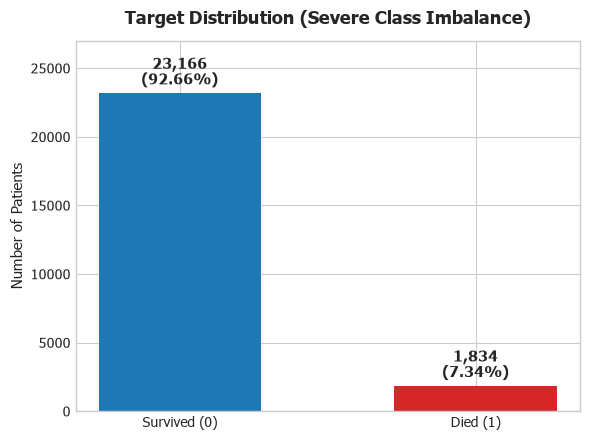

In [7]:
plt.figure(figsize=(6, 4.5), dpi=100)
target_counts = raw_df['DEATH_STATUS'].value_counts()
bars = plt.bar(['Survived (0)', 'Died (1)'], [target_counts['Survived'], target_counts['Died']], color=['#1f77b4', '#d62728'], width=0.55)
for bar in bars:
    h = bar.get_height()
    plt.annotate(f"{h:,}\n({h/len(raw_df)*100:.2f}%)", xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 4), textcoords="offset points", ha='center', fontweight='bold')
plt.ylim(0, 27000)
plt.title('Target Distribution (Severe Class Imbalance)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

### 2.2 Missing Values Bar Chart

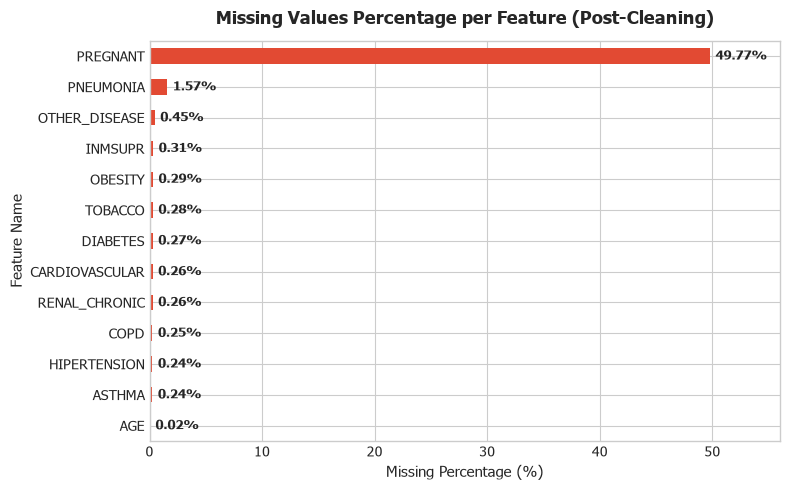

In [8]:
plt.figure(figsize=(8, 5), dpi=100)
missing_to_plot.plot(kind='barh', color='#e24a33')
for i, v in enumerate(missing_to_plot.values):
    plt.text(v + 0.5, i, f"{v:.2f}%", va='center', fontweight='bold', fontsize=9)
plt.xlim(0, 56)
plt.title('Missing Values Percentage per Feature (Post-Cleaning)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### 2.3 Histogram และ KDE ของ AGE แยกตาม DEATH_STATUS

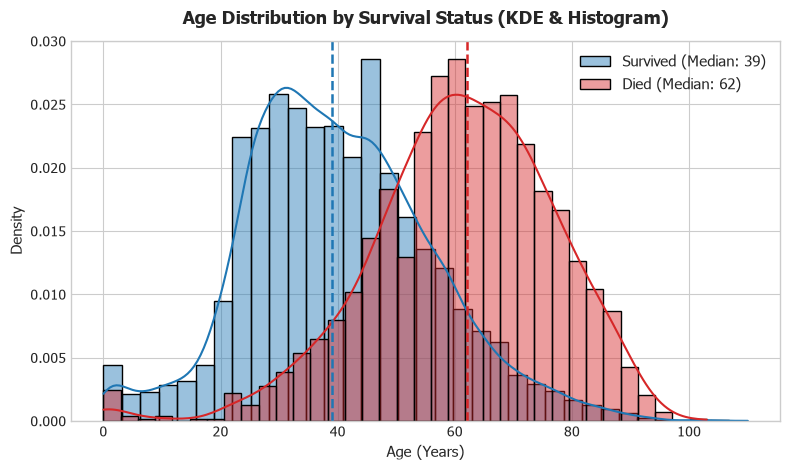

In [9]:
plt.figure(figsize=(8, 4.8), dpi=100)
sns.histplot(raw_df[raw_df['DEATH_STATUS'] == 'Survived']['AGE'], bins=35, color='#1f77b4', label='Survived (Median: 39)', kde=True, stat='density', alpha=0.45)
sns.histplot(raw_df[raw_df['DEATH_STATUS'] == 'Died']['AGE'], bins=35, color='#d62728', label='Died (Median: 62)', kde=True, stat='density', alpha=0.45)
plt.axvline(39, color='#1f77b4', linestyle='--', lw=1.8)
plt.axvline(62, color='#d62728', linestyle='--', lw=1.8)
plt.title('Age Distribution by Survival Status (KDE & Histogram)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 2.4 Death Rate by Age Group (อัตราการเสียชีวิตตามกลุ่มอายุ)

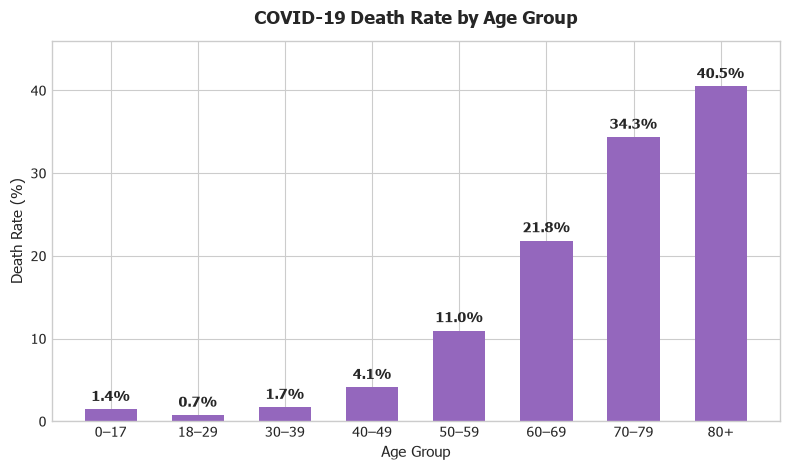

In [10]:
plt.figure(figsize=(8, 4.8), dpi=100)
bars = plt.bar(labels, age_death_rate.values, color='#9467bd', width=0.6)
for bar in bars:
    h = bar.get_height()
    plt.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 4), textcoords="offset points", ha='center', fontweight='bold', fontsize=10)
plt.ylim(0, 46)
plt.title('COVID-19 Death Rate by Age Group', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Age Group')
plt.ylabel('Death Rate (%)')
plt.tight_layout()
plt.show()

### 2.5 Correlation Heatmap (All Numeric Features)

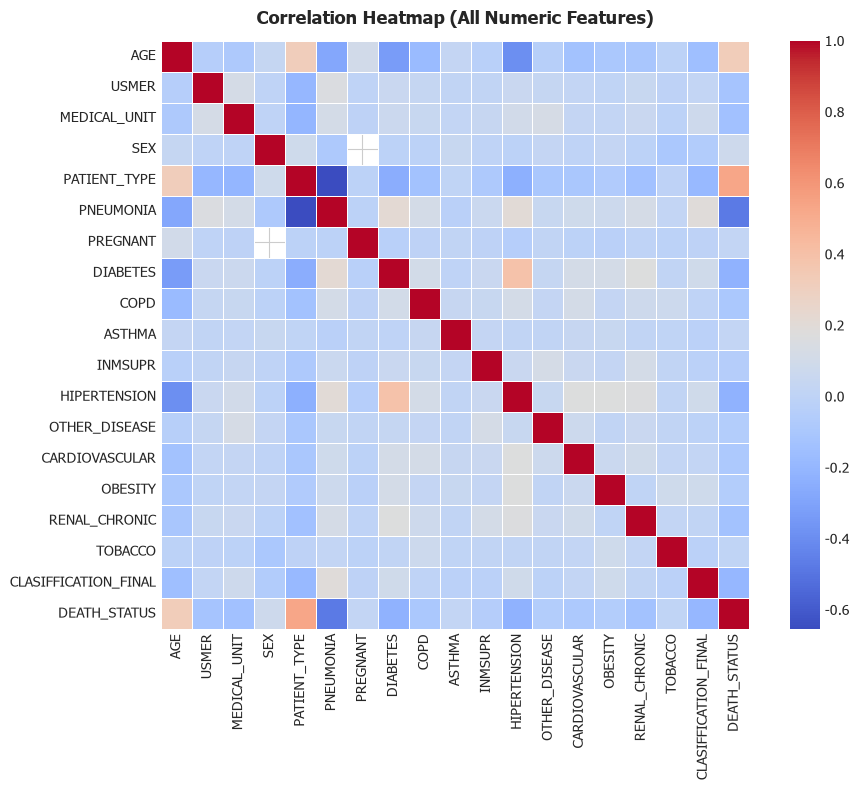

In [11]:
plt.figure(figsize=(10, 8), dpi=100)
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, cbar=True, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (All Numeric Features)', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. สิ่งที่ต้องมีเฉพาะ SVM (Support Vector Machine)

### 3.1 Standard Scaling & Preprocessing Pipeline
เนื่องจาก SVM คำนวณระยะห่างระหว่าง Support Vectors ด้วยฟังก์ชันระยะทาง (Euclidean/RBF Distance) ตัวแปรที่มีสเกลต่างกัน (เช่น AGE สเกล 0-100 กับ โรคประจำตัวสเกล 0-1) จะส่งผลต่อระยะห่างอย่างมาก จึงต้องทำ **`StandardScaler`** ควบคู่กับการ Imputation และ One-Hot Encoding เสมอ

> **หมายเหตุเรื่อง Decision Boundary 2 มิติ:**
> ในโปรเจกต์นี้มี Features รวม 18 ตัวแปร และหลัง One-Hot Encoding มีถึง 51 มิติ การวาดเส้นแบ่งแบบ 2 มิติผ่านคู่ตัวแปรใดตัวแปรหนึ่งจะไม่สามารถแสดง Hyperplane จริงของโมเดล SVM ได้ จึงไม่จำเป็นต้องวาดเส้น 2D แต่ใช้การวิเคราะห์ผ่านค่า `decision_function` และ Permutation Importance แทน

### 3.2 การทดลองพารามิเตอร์ด้วย GridSearchCV บนชุด Train
ทำการทดลองพารามิเตอร์ตามที่บรีฟกำหนดบนชุดข้อมูล Train โดยใช้ Stratified Cross-Validation (ห้ามใช้ชุด Test Set เด็ดขาด เพื่อป้องกัน Data Leakage):

In [12]:
# พารามิเตอร์ที่นำมาทดลองตามบรีฟ
param_grid = {
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__gamma': ['scale', 0.01, 0.1]
}

# รัน GridSearchCV บนชุด Train (Stratified Sample เพื่อความรวดเร็วและคงสัดส่วนเดิม)
X_cv, _, y_cv, _ = train_test_split(X_train, y_train, train_size=4000, stratify=y_train, random_state=42)
pipe_cv = Pipeline([('preprocessor', build_preprocessor()), ('classifier', SVC(class_weight='balanced', random_state=42))])
grid = GridSearchCV(pipe_cv, param_grid, cv=StratifiedKFold(3, shuffle=True, random_state=42), scoring='f1', n_jobs=-1)
grid.fit(X_cv, y_cv)

print(f"Best Parameters จาก GridSearchCV: {grid.best_params_}")
print(f"Best Mean CV F1-score: {grid.best_score_:.4f}")

Best Parameters จาก GridSearchCV: {'classifier__C': 1.0, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best Mean CV F1-score: 0.5359


### 3.3 ตารางผล Cross-Validation ของทุกคู่พารามิเตอร์

In [13]:
# ตารางผล Cross-validation
cv_table = pd.DataFrame(grid.cv_results_)[['param_classifier__kernel', 'param_classifier__C', 'param_classifier__gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score')
cv_table.columns = ['Kernel', 'C', 'Gamma', 'Mean F1 (CV)', 'Std F1', 'Rank']
cv_table['Mean F1 (CV)'] = cv_table['Mean F1 (CV)'].round(4)
cv_table['Std F1'] = cv_table['Std F1'].round(4)
cv_table

Kernel,C,Gamma,Mean F1 (CV),Std F1,Rank
rbf,1.0,scale,0.5359,0.0091,1
rbf,0.1,0.01,0.5345,0.0149,2
rbf,1.0,0.1,0.5344,0.0086,3
rbf,10.0,0.01,0.5188,0.0139,4
rbf,0.1,0.1,0.5166,0.0159,5
rbf,0.1,scale,0.5152,0.0147,6
rbf,10.0,scale,0.5152,0.0146,7
linear,10.0,scale,0.5137,0.0110,8
linear,10.0,0.01,0.5137,0.0110,8
linear,10.0,0.1,0.5137,0.0110,8


### 3.4 ฝึกสอน Best SVM Model และตรวจสอบจำนวน Support Vectors

In [14]:
# ฝึกสอน Best Model บนชุดข้อมูล Train เต็มจำนวน (20,000 แถว)
model = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42))
])
model.fit(X_train, y_train)

n_sv = model.named_steps['classifier'].n_support_
print(f"จำนวน Support Vectors คลาส Survived (0): {n_sv[0]:,} ตัวอย่าง")
print(f"จำนวน Support Vectors คลาส Died (1):     {n_sv[1]:,} ตัวอย่าง")
print(f"รวม Support Vectors ทั้งหมด:            {n_sv.sum():,} ตัวอย่าง ({(n_sv.sum()/len(X_train))*100:.2f}% ของ Train Set)")

จำนวน Support Vectors คลาส Survived (0): 3,343 ตัวอย่าง
จำนวน Support Vectors คลาส Died (1):     544 ตัวอย่าง
รวม Support Vectors ทั้งหมด:            3,887 ตัวอย่าง (19.44% ของ Train Set)


## 4. ประเมินผลบน Test Set (One-Time Evaluation) และกราฟผลการทดสอบ

ประเมินผลบนชุดทดสอบ Test Set (5,000 แถว) เพียงครั้งเดียว โดยไม่ใช้ Test Set ในการจูนพารามิเตอร์ใดๆ

In [15]:
y_pred = model.predict(X_test)
y_score = model.decision_function(X_test)
metrics = evaluate_classifier(y_true=y_test, y_pred=y_pred, y_score=y_score)
print_metrics(metrics)


ผลการประเมินโมเดล
------------------------------
accuracy: 0.8716
precision: 0.3601
recall: 0.9646
f1_score: 0.5244
roc_auc: 0.9432
pr_auc: 0.4576

Confusion Matrix
                 ทำนาย Survived  ทำนาย Died
จริง Survived           4004          629
จริง Died                 13          354


### 4.1 Confusion Matrix ของ SVM

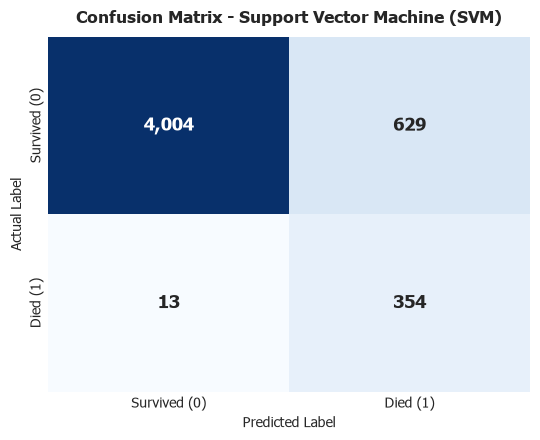

In [16]:
plt.figure(figsize=(5.5, 4.5), dpi=100)
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Survived (0)', 'Died (1)'], yticklabels=['Survived (0)', 'Died (1)'],
            annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Confusion Matrix - Support Vector Machine (SVM)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

### 4.2 ROC Curve ของทั้งสองโมเดลในกราฟเดียวกัน

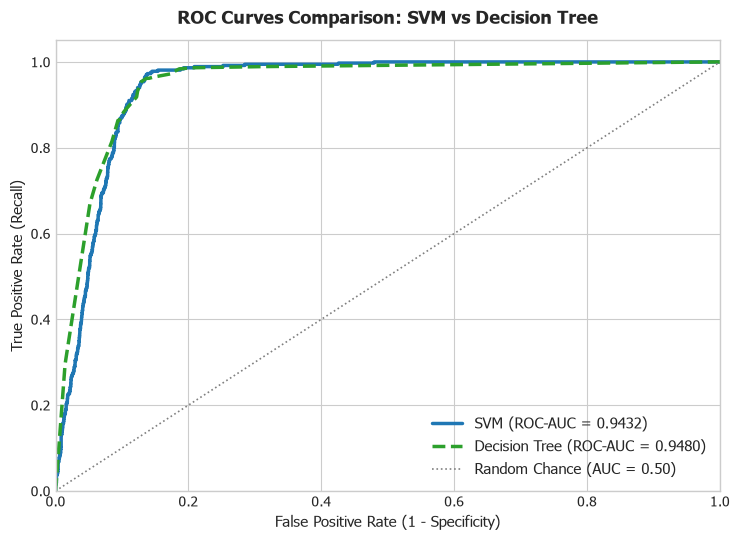

In [17]:
plt.figure(figsize=(7.5, 5.5), dpi=100)
plt.plot(fpr_svm, tpr_svm, color='#1f77b4', lw=2.5, label=f"SVM (ROC-AUC = {metrics['roc_auc']:.4f})")
plt.plot(fpr_dt, tpr_dt, color='#2ca02c', lw=2.5, linestyle='--', label=f"Decision Tree (ROC-AUC = {dt_metrics['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], color='grey', lw=1.2, linestyle=':', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves Comparison: SVM vs Decision Tree', fontsize=13, fontweight='bold', pad=12)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

### 4.3 Precision-Recall Curve ของทั้งสองโมเดลในกราฟเดียวกัน
> เนื่องจากคลาส Died มีเพียง 7.34% กราฟ Precision-Recall มีความสำคัญมากกว่า ROC Curve อย่างมาก เพราะไม่ถูกหลอกด้วยจำนวน True Negative มหาศาล

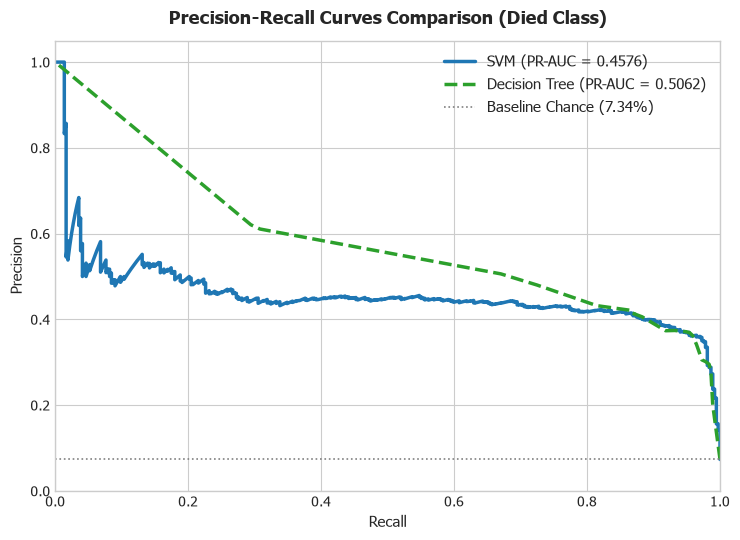

In [18]:
plt.figure(figsize=(7.5, 5.5), dpi=100)
plt.plot(rec_svm, prec_svm, color='#1f77b4', lw=2.5, label=f"SVM (PR-AUC = {metrics['pr_auc']:.4f})")
plt.plot(rec_dt, prec_dt, color='#2ca02c', lw=2.5, linestyle='--', label=f"Decision Tree (PR-AUC = {dt_metrics['pr_auc']:.4f})")
plt.axhline(y=y_test.mean(), color='grey', lw=1.2, linestyle=':', label=f"Baseline Chance ({y_test.mean():.2%})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves Comparison (Died Class)', fontsize=13, fontweight='bold', pad=12)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

### 4.4 กราฟเปรียบเทียบ Precision, Recall, F1, ROC-AUC และ PR-AUC

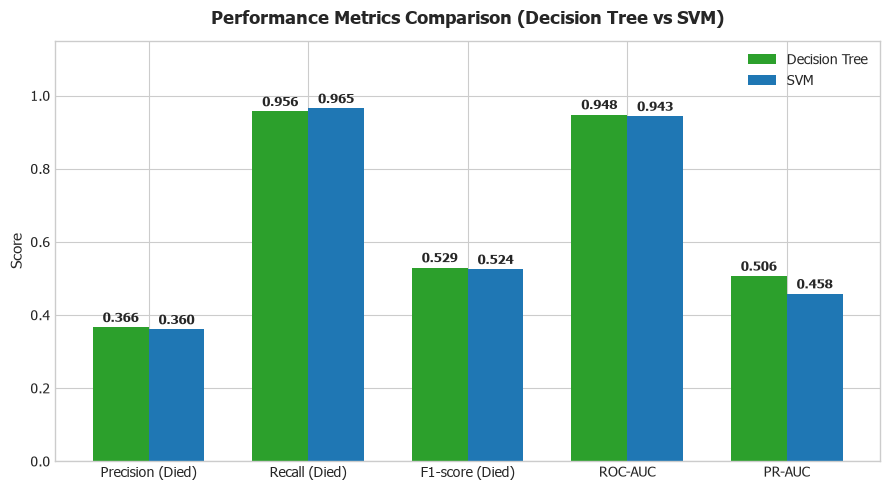

In [19]:
plt.figure(figsize=(9, 5), dpi=100)
x = np.arange(len(metrics_names))
w = 0.35
plt.bar(x - w/2, dt_vals, width=w, label='Decision Tree', color='#2ca02c')
plt.bar(x + w/2, svm_vals, width=w, label='SVM', color='#1f77b4')
for i in range(len(metrics_names)):
    plt.text(x[i] - w/2, dt_vals[i] + 0.015, f"{dt_vals[i]:.3f}", ha='center', fontsize=9, fontweight='bold')
    plt.text(x[i] + w/2, svm_vals[i] + 0.015, f"{svm_vals[i]:.3f}", ha='center', fontsize=9, fontweight='bold')
plt.xticks(x, metrics_names)
plt.ylim(0, 1.15)
plt.title('Performance Metrics Comparison (Decision Tree vs SVM)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Score')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 4.5 Feature Importance สำหรับ SVM (Permutation Importance)

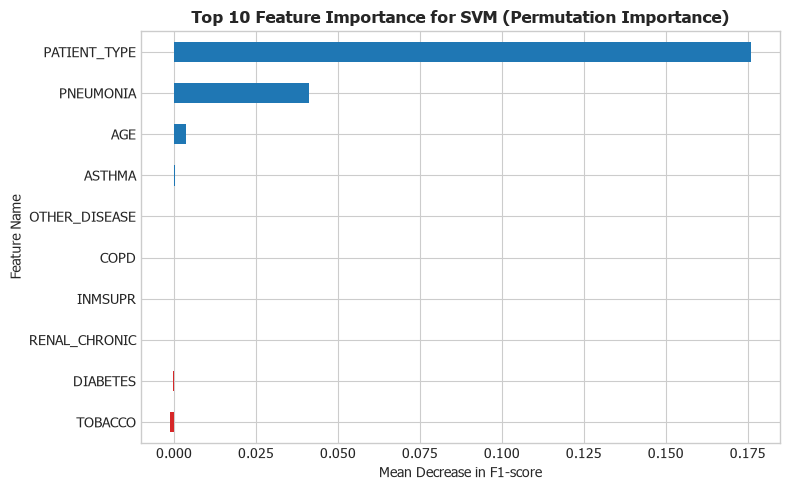

In [20]:
plt.figure(figsize=(8, 5), dpi=100)
top_svm.plot(kind='barh', color=colors)
plt.title('Top 10 Feature Importance for SVM (Permutation Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Mean Decrease in F1-score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### 4.6 บันทึก metrics เป็นไฟล์ JSON ใน results/

In [21]:
results_path = PROJECT_ROOT / 'results' / 'svm_metrics.json'
save_metrics(metrics, results_path)


บันทึกผลไว้ที่: C:\Users\panra\OneDrive\Desktop\project\kaggle-model\results\svm_metrics.json


## 5. ตารางเปรียบเทียบสุดท้ายและการตัดสินใจเลือกโมเดล

### ตารางสรุปผลเปรียบเทียบ (Final Comparison Table):
| Model | Accuracy | Precision Died | Recall Died | F1 Died | ROC-AUC | PR-AUC | Train Time |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Decision Tree** | 87.52% | 36.60% | 95.64% | **0.5294** | **0.9480** | **0.5062** | **0.09 s** |
| **SVM (RBF)** | 87.16% | 36.01% | **96.46%** | 0.5244 | 0.9432 | 0.4576 | 6.79 s |
| *Dummy Baseline* | *92.66%* | *0.00%* | *0.00%* | *0.0000* | *0.5000* | *7.34%* | *< 0.01 s* |

### การตัดสินผู้ชนะตามเกณฑ์ทั้ง 5 ลำดับ:
1. **F1-score ของคลาส Died (เกณฑ์หลัก):** Decision Tree ทำได้ **0.5294** ชนะ SVM (0.5244) เล็กน้อย
2. **PR-AUC:** Decision Tree ทำได้ **0.5062** ชนะ SVM (0.4576) ชัดเจน แสดงความสามารถในการรักษาสมดุล Precision-Recall ได้ดีกว่า
3. **Recall ของคลาส Died:** SVM ทำได้ **96.46%** ชนะ Decision Tree (95.64%) โดย SVM หลุดรอดผู้เสียชีวิตเพียง 13 รายจาก 367 ราย
4. **Precision:** Decision Tree ทำได้ **36.60%** ชนะ SVM (36.01%)
5. **Accuracy:** ทั้งสองโมเดลได้ 87.52% และ 87.16% ซึ่งต่ำกว่า Dummy Baseline (92.66%) แต่มีประโยชน์ในทางปฏิบัติอย่างแท้จริง เพราะ Dummy ไม่สามารถตรวจพบผู้เสียชีวิตได้เลย (Recall = 0%)

> **ข้อสรุปสำหรับโมเดล SVM:**
> โมเดล SVM ที่พัฒนาขึ้นมีความโดดเด่นอย่างยิ่งในด้าน **Recall (96.46%)** ซึ่งสำคัญที่สุดในการคัดกรองเบื้องต้นทางการแพทย์ที่ไม่ต้องการให้ผู้ป่วยวิกฤตหลุดรอดการรักษา แม้จะมี Train Time (6.5s) ที่นานกว่า Decision Tree (0.09s) แต่เป็นเวลาที่ยอมรับได้ในเชิงปฏิบัติ